# PROJECT 2 — Clean LOSO Pipeline

This notebook removes the old random/case-level split, S11-only testing, and duplicate training blocks.

**Rule for all experiments:** evaluation must be LOSO-style subject-wise evaluation.

- One subject is held out as **test**.
- One different subject is used as **validation** for epoch/threshold selection.
- Remaining subjects are **training**.
- Thresholds are selected on validation only, then applied once to test.

To test a new model later, only change `build_model()` and `EXPERIMENT_NAME`.

## Section 00 — GPU setup

In [20]:
# ============================================================
# SECTION 00 — FORCE TRAINING ON PHYSICAL GPU 1
# ============================================================

import os

# Run this before importing torch. If torch was already imported, restart kernel first.
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])

CUDA_VISIBLE_DEVICES = 1


## Section 01 — Imports, config, seed

In [21]:
# ============================================================
# SECTION 01 — IMPORTS, CONFIG, SEED
# ============================================================

from pathlib import Path
import os, re, random, math, warnings, json, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from IPython.display import display

try:
    from scipy import ndimage as ndi
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    print("scipy not available: connected-component postprocessing will be skipped.")

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("Visible GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# Data paths
# ----------------------------
ROOT = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData")
IMG_DIR  = ROOT / "FIR_input"
MASK_DIR = ROOT / "PixelLabelData"

# ----------------------------
# Output paths
# ----------------------------
EXPERIMENT_NAME = "loso_hier_unet_baseline_clean"
OUT_DIR = Path("./THERMO_LOSO_RESULTS")
EXP_DIR = OUT_DIR / EXPERIMENT_NAME
CSV_DIR = EXP_DIR / "csv"
PLOT_DIR = EXP_DIR / "plots"
CACHE_DIR = EXP_DIR / "cache_npz"
MODEL_DIR = EXP_DIR / "models"

for d in [CSV_DIR, PLOT_DIR, CACHE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Image/label config
# ----------------------------
IMG_SIZE = (320, 256)   # PIL size = (W, H)
BACKGROUND_VALUES = [0, 1]
ABDOMEN_VALUE = 2
COLD_VALUE = 3

print("ROOT exists:", ROOT.exists())
print("IMG_DIR exists:", IMG_DIR.exists())
print("MASK_DIR exists:", MASK_DIR.exists())
print("Output:", EXP_DIR.resolve())

Torch: 2.5.1+cu121
CUDA available: True
Device: cuda:0
Visible GPU: Tesla V100-PCIE-32GB
ROOT exists: True
IMG_DIR exists: True
MASK_DIR exists: True
Output: /home/rafsan/Documents/GitHub/Cool_GANs/THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean


## Section 02 — Data utilities

In [22]:
# ============================================================
# SECTION 02 — DATA UTILITIES
# ============================================================

IMG_EXTS = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]

def natural_key(s):
    s = str(s)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]

def list_images(folder):
    paths = []
    folder = Path(folder)
    for ext in IMG_EXTS:
        paths += list(folder.rglob(f"*{ext}"))
        paths += list(folder.rglob(f"*{ext.upper()}"))
    return sorted(set(paths), key=natural_key)

def read_grayscale(path, size=IMG_SIZE, is_mask=False):
    img = Image.open(path).convert("L")
    if size is not None:
        resample = Image.NEAREST if is_mask else Image.BILINEAR
        img = img.resize(size, resample=resample)
    return np.array(img)

def robust_minmax01(x, p_low=1, p_high=99):
    x = x.astype(np.float32)
    lo = np.percentile(x, p_low)
    hi = np.percentile(x, p_high)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1).astype(np.float32)

def gradient_magnitude(img01):
    gy, gx = np.gradient(img01.astype(np.float32))
    g = np.sqrt(gx * gx + gy * gy)
    return robust_minmax01(g)

def local_mean_filter(x, k=21):
    xt = torch.tensor(x[None, None], dtype=torch.float32)
    pad = k // 2
    yt = F.avg_pool2d(
        F.pad(xt, (pad, pad, pad, pad), mode="reflect"),
        kernel_size=k,
        stride=1
    )
    return yt[0, 0].numpy()

def make_relative_thermal_channels(img_raw, body_soft=None):
    raw01 = robust_minmax01(img_raw)

    if body_soft is not None and np.any(body_soft > 0.25):
        roi = body_soft > 0.25
    else:
        roi = np.ones_like(raw01, dtype=bool)

    vals = raw01[roi]
    mu = float(np.mean(vals))
    sd = float(np.std(vals) + 1e-6)

    z = (raw01 - mu) / sd
    z01 = np.clip((z + 3) / 6, 0, 1).astype(np.float32)

    local_mean = local_mean_filter(raw01, k=21)
    coldness = np.maximum(0, local_mean - raw01)
    coldness = robust_minmax01(coldness)

    grad = gradient_magnitude(raw01)

    return np.stack([raw01, z01, coldness, grad], axis=0).astype(np.float32)

def mask_to_body_cold(mask):
    body = np.logical_or(mask == ABDOMEN_VALUE, mask == COLD_VALUE).astype(np.float32)
    cold = (mask == COLD_VALUE).astype(np.float32)
    return body, cold

def extract_subject_id(case_id):
    m = re.match(r"(S\d+)", str(case_id))
    if m:
        return m.group(1)
    return str(case_id).split("-")[0]

## Section 03 — Build manifest and cache

In [23]:
# ============================================================
# SECTION 03 — BUILD MANIFEST AND CACHE
# ============================================================

def build_manifest_by_order(img_dir=IMG_DIR, mask_dir=MASK_DIR):
    image_paths = sorted(list_images(img_dir), key=natural_key)
    mask_paths  = sorted(list_images(mask_dir), key=natural_key)

    print("Found FIR images:", len(image_paths))
    print("Found mask files:", len(mask_paths))

    if len(image_paths) == 0:
        raise ValueError("No FIR images found.")
    if len(mask_paths) == 0:
        raise ValueError("No mask files found.")

    if len(mask_paths) == len(image_paths):
        masks_per_image = 1
    elif len(mask_paths) % len(image_paths) == 0:
        masks_per_image = len(mask_paths) // len(image_paths)
    else:
        raise ValueError(
            f"Cannot pair safely: {len(image_paths)} images and {len(mask_paths)} masks. "
            "Need equal count or mask_count = image_count × doctors."
        )

    doctor_names = ["A", "B", "C", "D"]
    rows = []

    for i, img_path in enumerate(image_paths):
        for j in range(masks_per_image):
            mask_idx = i * masks_per_image + j
            mask_path = mask_paths[mask_idx]

            if masks_per_image == 1:
                doctor_id = "GT"
            else:
                doctor_id = doctor_names[j] if j < len(doctor_names) else f"D{j+1}"

            rows.append({
                "case_id": img_path.stem,
                "subject_id": extract_subject_id(img_path.stem),
                "image_path": str(img_path),
                "image_name": img_path.name,
                "mask_path": str(mask_path),
                "mask_name": mask_path.name,
                "doctor_id": doctor_id,
                "try_id": j + 1,
            })

    manifest = pd.DataFrame(rows)
    manifest.to_csv(CSV_DIR / "03_manifest_paired_masks.csv", index=False)

    case_summary = (
        manifest.groupby("case_id")
        .agg(
            subject_id=("subject_id", "first"),
            image_path=("image_path", "first"),
            n_masks=("mask_path", "count"),
            doctors=("doctor_id", lambda x: ",".join(sorted(set(map(str, x))))),
        )
        .reset_index()
    )
    case_summary.to_csv(CSV_DIR / "04_case_summary.csv", index=False)

    print("Masks per image:", masks_per_image)
    print("Total cases:", len(case_summary))
    display(case_summary.head())

    return manifest, case_summary


def build_case_cache(case_id, rows):
    image_path = Path(rows.iloc[0]["image_path"])
    img_raw = read_grayscale(image_path, size=IMG_SIZE, is_mask=False)

    body_list, cold_list = [], []
    value_rows = []

    for _, r in rows.iterrows():
        mask_path = Path(r["mask_path"])
        mask = read_grayscale(mask_path, size=IMG_SIZE, is_mask=True)

        vals, counts = np.unique(mask, return_counts=True)
        for v, c in zip(vals, counts):
            value_rows.append({
                "case_id": case_id,
                "mask_name": mask_path.name,
                "doctor_id": r["doctor_id"],
                "label_value": int(v),
                "pixel_count": int(c),
            })

        body, cold = mask_to_body_cold(mask)
        body_list.append(body)
        cold_list.append(cold)

    body_stack = np.stack(body_list, axis=0)
    cold_stack = np.stack(cold_list, axis=0)

    body_soft = body_stack.mean(axis=0).astype(np.float32)
    cold_soft = cold_stack.mean(axis=0).astype(np.float32)
    cold_soft = np.minimum(cold_soft, body_soft)

    x4 = make_relative_thermal_channels(img_raw, body_soft=body_soft)

    return {
        "img_raw": img_raw.astype(np.float32),
        "x4": x4.astype(np.float32),
        "body_soft": body_soft.astype(np.float32),
        "cold_soft": cold_soft.astype(np.float32),
        "value_rows": value_rows,
    }


def build_cache(manifest):
    cache_rows = []
    value_rows_all = []

    for case_id, rows in manifest.groupby("case_id"):
        rows = rows.reset_index(drop=True)
        d = build_case_cache(case_id, rows)
        out_path = CACHE_DIR / f"{case_id}.npz"

        np.savez_compressed(
            out_path,
            img_raw=d["img_raw"],
            x4=d["x4"],
            body_soft=d["body_soft"],
            cold_soft=d["cold_soft"],
        )

        body_pixels = float(d["body_soft"].sum())
        cold_pixels = float(d["cold_soft"].sum())

        cache_rows.append({
            "case_id": case_id,
            "subject_id": extract_subject_id(case_id),
            "npz_path": str(out_path),
            "n_masks": len(rows),
            "doctors": ",".join(sorted(set(rows["doctor_id"].astype(str)))),
            "body_pixels": body_pixels,
            "cold_pixels": cold_pixels,
            "cold_fraction_in_body": cold_pixels / (body_pixels + 1e-8),
            "cold_fraction_image": cold_pixels / float(d["cold_soft"].size),
        })
        value_rows_all.extend(d["value_rows"])

    cache_df = pd.DataFrame(cache_rows)
    label_value_df = pd.DataFrame(value_rows_all)

    cache_df.to_csv(CSV_DIR / "05_consensus_cache_index.csv", index=False)
    label_value_df.to_csv(CSV_DIR / "06_mask_label_value_summary.csv", index=False)

    print("Cached cases:", len(cache_df))
    display(cache_df.head())
    return cache_df, label_value_df

manifest, case_summary = build_manifest_by_order()
cache_df, label_value_df = build_cache(manifest)

Found FIR images: 79
Found mask files: 79
Masks per image: 1
Total cases: 79


,case_id,subject_id,image_path,n_masks,doctors
0,S05-B-2,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,1,GT
1,S05-B-3,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,1,GT
2,S05-C-1,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,1,GT
3,S05-C-2,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,1,GT
4,S05-C-3,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,1,GT


Cached cases: 79


,case_id,subject_id,npz_path,n_masks,doctors,body_pixels,cold_pixels,cold_fraction_in_body,cold_fraction_image
0,S05-B-2,S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,1,GT,29231.0,4079.0,0.139544,0.049792
1,S05-B-3,S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,1,GT,29027.0,2324.0,0.080063,0.028369
2,S05-C-1,S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,1,GT,29324.0,871.0,0.029703,0.010632
3,S05-C-2,S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,1,GT,28034.0,554.0,0.019762,0.006763
4,S05-C-3,S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,1,GT,29153.0,608.0,0.020855,0.007422


## Section 04 — QC table

Subject-level statistics:


body_pixels                                          cold_pixels  \
                 count          mean   median      min      max       count   
subject_id                                                                    
S05                  8  29463.750000  29277.5  28034.0  31000.0           8   
S06                 11  15443.090909  15501.0  14788.0  16015.0          11   
S07                 12  16339.416667  15038.0  14025.0  21475.0          12   
S08                 12  15806.333333  16524.5      0.0  20524.0          12   
S09                 12  12929.916667  14307.0   7915.0  15638.0          12   
S10                 12   9148.583333   9353.0   8034.0  10048.0          12   
S11                 12  12974.416667  13038.5  11921.0  14153.0          12   

                                               cold_fraction_in_body  \
                   mean  median    min     max                 count   
subject_id                                                             
S05         1323.375000   739.5  304.0  4079.0                     8   
S06         1402.363636   490.0  193.0  9837.0                    11   
S07         1550.333333   947.5   97.0  6765.0                    12   
S08          401.083333   390.0    0.0   911.0                    12   
S09          328.500000   248.0   54.0   691.0                    12   
S10          258.833333   170.5   41.0   723.0                    12   
S11         1986.166667  1310.0  501.0  4483.0                    12   

                                                    
                mean    median       min       max  
subject_id                                          
S05         0.045049  0.025279  0.010017  0.139544  
S06         0.093053  0.032833  0.012527  0.665202  
S07         0.101649  0.065408  0.004767  0.422074  
S08         0.023864  0.021805  0.000000  0.059133  
S09         0.024977  0.026538  0.003877  0.047055  
S10         0.029027  0.017896  0.004239  0.089993  
S11         0.153771  0.098212  0.041149  0.354808

Invalid cases:


,case_id,subject_id,npz_path,n_masks,doctors,body_pixels,cold_pixels,cold_fraction_in_body,cold_fraction_image,valid_case,zero_cold
33,S08-A-3,S08,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,1,GT,0.0,0.0,0.0,0.0,False,True


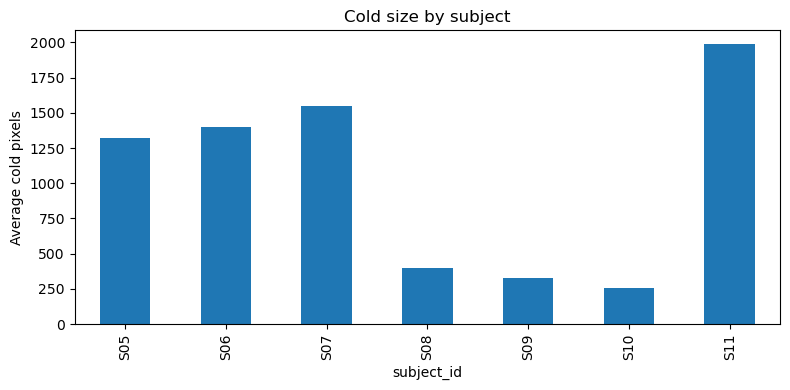

Valid subjects: ['S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11']
Valid cases: 78


In [24]:
# ============================================================
# SECTION 04 — QC TABLE
# ============================================================

def build_qc_table(cache_df, min_body_pixels=100):
    qc_df = cache_df.copy().reset_index(drop=True)
    qc_df["valid_case"] = qc_df["body_pixels"] > min_body_pixels
    qc_df["zero_cold"] = qc_df["cold_pixels"] <= 0

    qc_df.to_csv(CSV_DIR / "07_qc_table.csv", index=False)

    print("Subject-level statistics:")
    display(
        qc_df.groupby("subject_id")[["body_pixels", "cold_pixels", "cold_fraction_in_body"]]
        .agg(["count", "mean", "median", "min", "max"])
    )

    print("Invalid cases:")
    display(qc_df[qc_df["valid_case"] == False])

    plt.figure(figsize=(8, 4))
    qc_df.groupby("subject_id")["cold_pixels"].mean().plot(kind="bar")
    plt.ylabel("Average cold pixels")
    plt.title("Cold size by subject")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "07_cold_pixels_by_subject.png", dpi=200)
    plt.show()

    return qc_df[qc_df["valid_case"]].copy().reset_index(drop=True)

case_df_all = build_qc_table(cache_df)
subjects = sorted(case_df_all["subject_id"].unique())
print("Valid subjects:", subjects)
print("Valid cases:", len(case_df_all))

## Section 05 — Dataset and balanced sampler

In [25]:
# ============================================================
# SECTION 05 — DATASET AND BALANCED SAMPLER
# ============================================================

class ThermoHierDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _augment(self, x, body, cold):
        if random.random() < 0.5:
            x = np.flip(x, axis=2).copy()
            body = np.flip(body, axis=2).copy()
            cold = np.flip(cold, axis=2).copy()

        if random.random() < 0.6:
            scale = np.random.uniform(0.93, 1.07)
            shift = np.random.uniform(-0.035, 0.035)
            x = np.clip(x * scale + shift, 0, 1).astype(np.float32)

        if random.random() < 0.35:
            noise = np.random.normal(0, 0.012, size=x.shape).astype(np.float32)
            x = np.clip(x + noise, 0, 1).astype(np.float32)

        return x, body, cold

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        d = np.load(row["npz_path"])

        x = d["x4"].astype(np.float32)
        body = d["body_soft"][None].astype(np.float32)
        cold = d["cold_soft"][None].astype(np.float32)

        if self.augment:
            x, body, cold = self._augment(x, body, cold)

        return {
            "x": torch.tensor(x, dtype=torch.float32),
            "body": torch.tensor(body, dtype=torch.float32),
            "cold": torch.tensor(cold, dtype=torch.float32),
            "case_id": row["case_id"],
        }


def add_cold_size_bins(train_df):
    df = train_df.copy().reset_index(drop=True)
    nonzero = df[df["cold_pixels"] > 0]["cold_fraction_in_body"]

    if len(nonzero) >= 3:
        q1 = nonzero.quantile(0.33)
        q2 = nonzero.quantile(0.66)
    else:
        q1, q2 = 0.01, 0.05

    def bin_one(row):
        v = row["cold_fraction_in_body"]
        if row["cold_pixels"] <= 0:
            return "zero"
        if v <= q1:
            return "small"
        if v <= q2:
            return "medium"
        return "large"

    df["cold_bin"] = df.apply(bin_one, axis=1)
    return df


def make_balanced_sampler(train_df):
    counts = train_df["cold_bin"].value_counts().to_dict()
    weights = [1.0 / counts[row["cold_bin"]] for _, row in train_df.iterrows()]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights) * 2,
        replacement=True,
    )

## Section 06 — Model factory

For the next experiment, change only `EXPERIMENT_NAME` and `build_model()` if needed. The LOSO evaluation code below remains the same.

In [26]:
# ============================================================
# SECTION 06 — MODEL FACTORY
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self, in_ch=4, out_ch=2, base=24):
        super().__init__()
        self.e1 = ConvBlock(in_ch, base)
        self.e2 = ConvBlock(base, base * 2)
        self.e3 = ConvBlock(base * 2, base * 4, dropout=0.05)
        self.e4 = ConvBlock(base * 4, base * 8, dropout=0.10)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base * 8, base * 16, dropout=0.15)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.d4 = ConvBlock(base * 16, base * 8, dropout=0.10)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.d3 = ConvBlock(base * 8, base * 4, dropout=0.05)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.d2 = ConvBlock(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.d1 = ConvBlock(base * 2, base)
        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.d4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.d3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.d2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


def build_model():
    # Output channel 0 = body logit, channel 1 = cold logit
    return SmallUNet(in_ch=4, out_ch=2, base=24)

model_test = build_model().to(DEVICE)
print("Trainable parameters:", sum(p.numel() for p in model_test.parameters() if p.requires_grad))
del model_test
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Trainable parameters: 4368314


## Section 07 — Loss, post-processing, metrics

In [27]:
# ============================================================
# SECTION 07 — LOSS, POSTPROCESSING, METRICS
# ============================================================

def binary_dice_loss_from_logits(logits, target, eps=1e-6):
    prob = torch.sigmoid(logits)
    dims = (0, 2, 3)
    inter = (prob * target).sum(dims)
    denom = prob.sum(dims) + target.sum(dims)
    dice = (2 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()


def hierarchical_loss_fn(logits, body_gt, cold_gt):
    body_logit = logits[:, 0:1]
    cold_logit = logits[:, 1:2]

    body_prob = torch.sigmoid(body_logit)
    cold_prob = torch.sigmoid(cold_logit)

    body_bce = F.binary_cross_entropy_with_logits(body_logit, body_gt)
    cold_pos_weight = torch.tensor([2.0], device=logits.device)
    cold_bce = F.binary_cross_entropy_with_logits(cold_logit, cold_gt, pos_weight=cold_pos_weight)

    body_dice = binary_dice_loss_from_logits(body_logit, body_gt)
    cold_dice = binary_dice_loss_from_logits(cold_logit, cold_gt)

    outside_body_penalty = torch.relu(cold_prob - body_prob).mean()

    pred_cold_area = cold_prob.mean(dim=(1, 2, 3))
    true_cold_area = cold_gt.mean(dim=(1, 2, 3))
    area_loss = F.smooth_l1_loss(pred_cold_area, true_cold_area)

    total = (
        1.0 * (body_bce + body_dice)
        + 1.2 * (cold_bce + cold_dice)
        + 1.0 * outside_body_penalty
        + 50.0 * area_loss
    )

    parts = {
        "body_bce": float(body_bce.detach().cpu()),
        "cold_bce": float(cold_bce.detach().cpu()),
        "body_dice": float(body_dice.detach().cpu()),
        "cold_dice": float(cold_dice.detach().cpu()),
        "outside_body": float(outside_body_penalty.detach().cpu()),
        "area_loss": float(area_loss.detach().cpu()),
    }
    return total, parts


def remove_small_components(mask, min_size=30, keep_top_k=None):
    mask = mask.astype(bool)
    if (not SCIPY_AVAILABLE) or min_size <= 0:
        return mask

    lab, n = ndi.label(mask)
    if n == 0:
        return mask

    sizes = np.bincount(lab.ravel())
    valid_ids = [i for i in range(1, n + 1) if sizes[i] >= min_size]

    if keep_top_k is not None and len(valid_ids) > keep_top_k:
        valid_ids = sorted(valid_ids, key=lambda i: sizes[i], reverse=True)[:keep_top_k]

    return np.isin(lab, valid_ids)


def postprocess_body_cold(body_prob, cold_prob, body_thr=0.50, cold_thr=0.50, min_cold_cc=30):
    body_mask = body_prob >= body_thr

    if SCIPY_AVAILABLE:
        body_mask = ndi.binary_fill_holes(body_mask)
        body_mask = remove_small_components(body_mask, min_size=300, keep_top_k=1)

    cold_mask = (cold_prob >= cold_thr) & body_mask
    cold_mask = remove_small_components(cold_mask, min_size=min_cold_cc, keep_top_k=None)
    cold_mask = cold_mask & body_mask

    return body_mask.astype(bool), cold_mask.astype(bool)


def metrics_for_binary(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)

    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    tn = np.logical_and(~pred_mask, ~gt_mask).sum()

    return {
        "iou": float(tp / (tp + fp + fn + 1e-8)),
        "dice": float((2 * tp) / (2 * tp + fp + fn + 1e-8)),
        "sensitivity": float(tp / (tp + fn + 1e-8)),
        "specificity": float(tn / (tn + fp + 1e-8)),
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "gt_pixels": int(gt_mask.sum()),
        "pred_pixels": int(pred_mask.sum()),
    }


def evaluate_loader(model, loader, epoch, body_thr=0.50, cold_thr=0.50, min_cold_cc=30, split_name="val"):
    model.eval()
    rows = []

    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE)
            body_gt = batch["body"].to(DEVICE)
            cold_gt = batch["cold"].to(DEVICE)
            case_id = batch["case_id"][0]

            logits = model(x)
            loss, _ = hierarchical_loss_fn(logits, body_gt, cold_gt)

            body_prob = torch.sigmoid(logits[:, 0:1])[0, 0].detach().cpu().numpy()
            cold_prob = torch.sigmoid(logits[:, 1:2])[0, 0].detach().cpu().numpy()

            body_gt_np = body_gt[0, 0].detach().cpu().numpy() >= 0.5
            cold_gt_np = cold_gt[0, 0].detach().cpu().numpy() >= 0.5

            body_pred, cold_pred = postprocess_body_cold(
                body_prob,
                cold_prob,
                body_thr=body_thr,
                cold_thr=cold_thr,
                min_cold_cc=min_cold_cc,
            )

            for class_name, pred, gt in [
                ("body", body_pred, body_gt_np),
                ("cold", cold_pred, cold_gt_np),
            ]:
                m = metrics_for_binary(pred, gt)
                m.update({
                    "epoch": epoch,
                    "split": split_name,
                    "case_id": case_id,
                    "class": class_name,
                    "body_thr": float(body_thr),
                    "cold_thr": float(cold_thr),
                    "min_cold_cc": int(min_cold_cc),
                    "loss": float(loss.detach().cpu()),
                })
                rows.append(m)

    df = pd.DataFrame(rows)
    summary = (
        df.groupby("class")[["iou", "dice", "sensitivity", "specificity", "gt_pixels", "pred_pixels", "loss"]]
        .mean()
        .reset_index()
    )

    body_iou = float(summary[summary["class"] == "body"]["iou"].iloc[0])
    cold_iou = float(summary[summary["class"] == "cold"]["iou"].iloc[0])
    cold_sens = float(summary[summary["class"] == "cold"]["sensitivity"].iloc[0])
    cold_spec = float(summary[summary["class"] == "cold"]["specificity"].iloc[0])
    mean_loss = float(df["loss"].mean())

    return df, summary, mean_loss, body_iou, cold_iou, cold_sens, cold_spec

## Section 08 — LOSO fold plan

This is the only evaluation protocol used from now on.

In [28]:
# ============================================================
# SECTION 08 — LOSO FOLD PLAN
# ============================================================

VAL_POLICY = "previous_subject"   # deterministic and leakage-free


def make_loso_plan(case_df):
    subjects = sorted(case_df["subject_id"].unique())
    rows = []

    for fold_id, test_subject in enumerate(subjects):
        test_idx = subjects.index(test_subject)
        val_subject = subjects[(test_idx - 1) % len(subjects)]
        train_subjects = [s for s in subjects if s not in [test_subject, val_subject]]

        rows.append({
            "fold_id": fold_id,
            "train_subjects": ",".join(train_subjects),
            "val_subject": val_subject,
            "test_subject": test_subject,
            "n_train": int(case_df[case_df["subject_id"].isin(train_subjects)].shape[0]),
            "n_val": int(case_df[case_df["subject_id"] == val_subject].shape[0]),
            "n_test": int(case_df[case_df["subject_id"] == test_subject].shape[0]),
        })

    plan_df = pd.DataFrame(rows)
    plan_df.to_csv(CSV_DIR / "08_loso_plan.csv", index=False)
    return plan_df

loso_plan_df = make_loso_plan(case_df_all)
display(loso_plan_df)

,fold_id,train_subjects,val_subject,test_subject,n_train,n_val,n_test
0,0,"S06,S07,S08,S09,S10",S11,S05,58,12,8
1,1,"S07,S08,S09,S10,S11",S05,S06,59,8,11
2,2,"S05,S08,S09,S10,S11",S06,S07,55,11,12
3,3,"S05,S06,S09,S10,S11",S07,S08,55,12,11
4,4,"S05,S06,S07,S10,S11",S08,S09,55,11,12
5,5,"S05,S06,S07,S08,S11",S09,S10,54,12,12
6,6,"S05,S06,S07,S08,S09",S10,S11,54,12,12


## Section 09 — Training utilities for one LOSO fold

In [29]:
# ============================================================
# SECTION 09 — TRAINING UTILITIES FOR ONE LOSO FOLD
# ============================================================

BATCH_SIZE = 4
EPOCHS = 180
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 40

DEFAULT_BODY_THR = 0.50
DEFAULT_COLD_THR = 0.50
DEFAULT_MIN_COLD_CC = 30

# BODY_THRESHOLDS = np.round(np.arange(0.30, 0.76, 0.05), 2)
# COLD_THRESHOLDS = np.round(np.arange(0.05, 0.91, 0.05), 2)
# MIN_CC_VALUES = [0, 20, 50, 100, 200]
# ============================================================
# MODIFY CONFIG — SAFER THRESHOLD SEARCH
# ============================================================

BODY_THRESHOLDS = np.round(np.arange(0.35, 0.76, 0.05), 2)
COLD_THRESHOLDS = np.round(np.arange(0.05, 0.81, 0.05), 2)

# Important: remove aggressive 100/200
MIN_CC_VALUES = [0, 20, 50]

# threshold-selection safety rules
THR_MIN_BODY_IOU = 0.65
THR_MIN_COLD_SENS = 0.20
THR_MIN_PRED_GT_RATIO = 0.25
THR_MAX_PRED_GT_RATIO = 4.00

def make_loaders_for_fold(case_df, fold_row):
    train_subjects = str(fold_row["train_subjects"]).split(",")
    val_subject = str(fold_row["val_subject"])
    test_subject = str(fold_row["test_subject"])

    train_df = case_df[case_df["subject_id"].isin(train_subjects)].reset_index(drop=True)
    val_df = case_df[case_df["subject_id"] == val_subject].reset_index(drop=True)
    test_df = case_df[case_df["subject_id"] == test_subject].reset_index(drop=True)

    assert set(train_df["subject_id"]).isdisjoint(set(val_df["subject_id"]))
    assert set(train_df["subject_id"]).isdisjoint(set(test_df["subject_id"]))
    assert set(val_df["subject_id"]).isdisjoint(set(test_df["subject_id"]))

    train_df = add_cold_size_bins(train_df)

    train_ds = ThermoHierDataset(train_df, augment=True)
    val_ds = ThermoHierDataset(val_df, augment=False)
    test_ds = ThermoHierDataset(test_df, augment=False)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        sampler=make_balanced_sampler(train_df),
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

    return train_df, val_df, test_df, train_loader, val_loader, test_loader




# ============================================================
# REPLACE FUNCTION — SAFER VALIDATION THRESHOLD SELECTION
# ============================================================

def select_threshold_on_validation(model, val_loader, fold_id, epoch):
    all_cases = []
    all_summaries = []

    for bt in BODY_THRESHOLDS:
        for ct in COLD_THRESHOLDS:
            for min_cc in MIN_CC_VALUES:
                case_df, summary_df, val_loss, body_iou, cold_iou, cold_sens, cold_spec = evaluate_loader(
                    model,
                    val_loader,
                    epoch=epoch,
                    body_thr=float(bt),
                    cold_thr=float(ct),
                    min_cold_cc=int(min_cc),
                    split_name="val",
                )

                case_df["fold_id"] = fold_id
                case_df["body_thr"] = float(bt)
                case_df["cold_thr"] = float(ct)
                case_df["min_cold_cc"] = int(min_cc)

                summary_df["fold_id"] = fold_id
                summary_df["body_thr"] = float(bt)
                summary_df["cold_thr"] = float(ct)
                summary_df["min_cold_cc"] = int(min_cc)

                all_cases.append(case_df)
                all_summaries.append(summary_df)

    val_cases_df = pd.concat(all_cases, ignore_index=True)
    val_summary_df = pd.concat(all_summaries, ignore_index=True)

    cold_val = val_summary_df[val_summary_df["class"] == "cold"].copy()
    body_val = val_summary_df[val_summary_df["class"] == "body"].copy()

    body_key = body_val[
        ["body_thr", "cold_thr", "min_cold_cc", "iou"]
    ].rename(columns={"iou": "body_iou"})

    cold_val = cold_val.merge(
        body_key,
        on=["body_thr", "cold_thr", "min_cold_cc"],
        how="left"
    )

    cold_val["pred_gt_ratio"] = cold_val["pred_pixels"] / (cold_val["gt_pixels"] + 1e-8)

    # Safety filter: avoid thresholds that predict almost nothing or too much cold
    candidate = cold_val[
        (cold_val["body_iou"] >= THR_MIN_BODY_IOU) &
        (cold_val["sensitivity"] >= THR_MIN_COLD_SENS) &
        (cold_val["pred_gt_ratio"] >= THR_MIN_PRED_GT_RATIO) &
        (cold_val["pred_gt_ratio"] <= THR_MAX_PRED_GT_RATIO)
    ].copy()

    if len(candidate) == 0:
        candidate = cold_val.copy()

    # Penalize cold area mismatch
    candidate["area_penalty"] = np.abs(np.log(candidate["pred_gt_ratio"] + 1e-8))

    candidate["selection_score"] = (
        candidate["iou"]
        + 0.25 * candidate["sensitivity"]
        + 0.10 * candidate["specificity"]
        + 0.05 * candidate["body_iou"]
        - 0.15 * candidate["area_penalty"]
    )

    best_row = candidate.sort_values(
        ["selection_score", "iou", "sensitivity"],
        ascending=[False, False, False]
    ).iloc[0]

    best_thr = {
        "body_thr": float(best_row["body_thr"]),
        "cold_thr": float(best_row["cold_thr"]),
        "min_cold_cc": int(best_row["min_cold_cc"]),
        "val_best_cold_iou_after_sweep": float(best_row["iou"]),
        "val_best_cold_sens_after_sweep": float(best_row["sensitivity"]),
        "val_best_cold_spec_after_sweep": float(best_row["specificity"]),
        "val_body_iou_at_selected_thr": float(best_row["body_iou"]),
        "val_pred_gt_ratio_at_selected_thr": float(best_row["pred_gt_ratio"]),
        "val_selection_score": float(best_row["selection_score"]),
    }

    return best_thr, val_cases_df, val_summary_df

## Section 10 — Run one LOSO fold

In [30]:
# ============================================================
# SECTION 10 — RUN ONE LOSO FOLD
# ============================================================


def run_one_loso_fold(case_df, fold_row):
    fold_id = int(fold_row["fold_id"])
    fold_name = f"fold_{fold_id:02d}_test_{fold_row['test_subject']}_val_{fold_row['val_subject']}"
    fold_dir = EXP_DIR / fold_name
    fold_csv_dir = fold_dir / "csv"
    fold_model_dir = fold_dir / "models"
    fold_plot_dir = fold_dir / "plots"
    for d in [fold_csv_dir, fold_model_dir, fold_plot_dir]:
        d.mkdir(parents=True, exist_ok=True)

    seed_everything(SEED + fold_id)

    train_df, val_df, test_df, train_loader, val_loader, test_loader = make_loaders_for_fold(case_df, fold_row)

    print("\n" + "=" * 80)
    print(f"LOSO {fold_name}")
    print("Train subjects:", sorted(train_df["subject_id"].unique()), "cases:", len(train_df))
    print("Val subject:", sorted(val_df["subject_id"].unique()), "cases:", len(val_df))
    print("Test subject:", sorted(test_df["subject_id"].unique()), "cases:", len(test_df))
    print("Train cold bins:")
    print(train_df["cold_bin"].value_counts())

    train_df.to_csv(fold_csv_dir / "train_cases.csv", index=False)
    val_df.to_csv(fold_csv_dir / "val_cases.csv", index=False)
    test_df.to_csv(fold_csv_dir / "test_cases.csv", index=False)

    model = build_model().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    best_model_path = fold_model_dir / f"best_{fold_name}.pt"
    best_score = -1.0
    best_epoch = -1
    best_cold_iou = -1.0
    bad_epochs = 0
    log_rows = []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for batch in train_loader:
            x = batch["x"].to(DEVICE)
            body_gt = batch["body"].to(DEVICE)
            cold_gt = batch["cold"].to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss, _ = hierarchical_loss_fn(logits, body_gt, cold_gt)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        scheduler.step()

        val_case_df, val_summary_df, val_loss, body_iou, cold_iou, cold_sens, cold_spec = evaluate_loader(
            model,
            val_loader,
            epoch=epoch,
            body_thr=DEFAULT_BODY_THR,
            cold_thr=DEFAULT_COLD_THR,
            min_cold_cc=DEFAULT_MIN_COLD_CC,
            split_name="val",
        )

        selection_score = cold_iou + 0.10 * body_iou

        row = {
            "fold_id": fold_id,
            "epoch": epoch,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "train_loss": float(np.mean(losses)),
            "val_loss": val_loss,
            "val_body_iou": body_iou,
            "val_cold_iou": cold_iou,
            "val_cold_sensitivity": cold_sens,
            "val_cold_specificity": cold_spec,
            "selection_score": selection_score,
        }
        log_rows.append(row)

        improved = selection_score > best_score
        if improved:
            best_score = selection_score
            best_epoch = epoch
            best_cold_iou = cold_iou
            bad_epochs = 0

            torch.save({
                "fold_id": fold_id,
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_score": best_score,
                "best_cold_iou": best_cold_iou,
                "experiment_name": EXPERIMENT_NAME,
                "fold_row": dict(fold_row),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": SEED + fold_id,
                    "default_body_thr": DEFAULT_BODY_THR,
                    "default_cold_thr": DEFAULT_COLD_THR,
                    "default_min_cold_cc": DEFAULT_MIN_COLD_CC,
                },
            }, best_model_path)

            val_summary_df.to_csv(fold_csv_dir / "best_val_summary_default_thr.csv", index=False)
            val_case_df.to_csv(fold_csv_dir / "best_val_per_case_default_thr.csv", index=False)
        else:
            bad_epochs += 1

        pd.DataFrame(log_rows).to_csv(fold_csv_dir / "train_log.csv", index=False)

        print(
            f"Fold {fold_id:02d} | Epoch {epoch:03d} | "
            f"train {row['train_loss']:.4f} | "
            f"val body {body_iou:.4f} | cold {cold_iou:.4f} | "
            f"sens {cold_sens:.4f} | spec {cold_spec:.4f} | "
            f"best cold {best_cold_iou:.4f} @ {best_epoch}"
        )

        if bad_epochs >= PATIENCE:
            print(f"Early stopping. Best epoch={best_epoch}, best default-threshold cold IoU={best_cold_iou:.4f}")
            break

    # Load best model and select thresholds on validation only
    ckpt = torch.load(best_model_path, map_location=DEVICE)
    model = build_model().to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    best_thr, val_sweep_cases, val_sweep_summary = select_threshold_on_validation(
        model,
        val_loader,
        fold_id=fold_id,
        epoch=ckpt["epoch"],
    )

    val_sweep_cases.to_csv(fold_csv_dir / "val_threshold_sweep_per_case.csv", index=False)
    val_sweep_summary.to_csv(fold_csv_dir / "val_threshold_sweep_summary.csv", index=False)

    # Evaluate test once using validation-selected thresholds
    test_case_df, test_summary_df, test_loss, test_body_iou, test_cold_iou, test_cold_sens, test_cold_spec = evaluate_loader(
        model,
        test_loader,
        epoch=ckpt["epoch"],
        body_thr=best_thr["body_thr"],
        cold_thr=best_thr["cold_thr"],
        min_cold_cc=best_thr["min_cold_cc"],
        split_name="test",
    )

    for k, v in best_thr.items():
        test_case_df[k] = v
        test_summary_df[k] = v

    test_case_df["fold_id"] = fold_id
    test_case_df["test_subject"] = fold_row["test_subject"]
    test_case_df["val_subject"] = fold_row["val_subject"]

    test_summary_df["fold_id"] = fold_id
    test_summary_df["test_subject"] = fold_row["test_subject"]
    test_summary_df["val_subject"] = fold_row["val_subject"]

    test_case_df.to_csv(fold_csv_dir / "test_per_case.csv", index=False)
    test_summary_df.to_csv(fold_csv_dir / "test_summary.csv", index=False)

    fold_result = {
        "fold_id": fold_id,
        "fold_name": fold_name,
        "model_path": str(best_model_path),
        "test_subject": fold_row["test_subject"],
        "val_subject": fold_row["val_subject"],
        "train_subjects": fold_row["train_subjects"],
        "best_epoch": int(ckpt["epoch"]),
        "selected_body_thr": best_thr["body_thr"],
        "selected_cold_thr": best_thr["cold_thr"],
        "selected_min_cold_cc": best_thr["min_cold_cc"],
        "val_best_cold_iou_after_sweep": best_thr["val_best_cold_iou_after_sweep"],
        "test_body_iou": float(test_summary_df[test_summary_df["class"] == "body"]["iou"].iloc[0]),
        "test_cold_iou": float(test_summary_df[test_summary_df["class"] == "cold"]["iou"].iloc[0]),
        "test_cold_sensitivity": float(test_summary_df[test_summary_df["class"] == "cold"]["sensitivity"].iloc[0]),
        "test_cold_specificity": float(test_summary_df[test_summary_df["class"] == "cold"]["specificity"].iloc[0]),
    }

    pd.DataFrame([fold_result]).to_csv(fold_csv_dir / "fold_result.csv", index=False)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return fold_result

## Section 11 — Run LOSO experiment

For final results, keep `LOSO_FOLDS_TO_RUN = None` so every subject is tested once. For quick debugging only, set `LOSO_FOLDS_TO_RUN = [0]`.

In [31]:
# ============================================================
# SECTION 11 — RUN LOSO EXPERIMENT
# ============================================================

LOSO_FOLDS_TO_RUN = None   # None = run all folds. Example debug: [0]

if LOSO_FOLDS_TO_RUN is None:
    folds_to_run = loso_plan_df["fold_id"].tolist()
else:
    folds_to_run = list(LOSO_FOLDS_TO_RUN)

all_fold_results = []

for fold_id in folds_to_run:
    fold_row = loso_plan_df[loso_plan_df["fold_id"] == fold_id].iloc[0]
    result = run_one_loso_fold(case_df_all, fold_row)
    all_fold_results.append(result)

fold_results_df = pd.DataFrame(all_fold_results)
fold_results_df.to_csv(CSV_DIR / "90_loso_fold_results.csv", index=False)

display(fold_results_df)
print("Saved:", CSV_DIR / "90_loso_fold_results.csv")


LOSO fold_00_test_S05_val_S11
Train subjects: ['S06', 'S07', 'S08', 'S09', 'S10'] cases: 58
Val subject: ['S11'] cases: 12
Test subject: ['S05'] cases: 8
Train cold bins:
cold_bin
large     20
medium    19
small     19
Name: count, dtype: int64
Fold 00 | Epoch 001 | train 6.2443 | val body 0.8131 | cold 0.0000 | sens 0.0000 | spec 1.0000 | best cold 0.0000 @ 1
Fold 00 | Epoch 002 | train 4.3863 | val body 0.8167 | cold 0.0000 | sens 0.0000 | spec 1.0000 | best cold 0.0000 @ 2
Fold 00 | Epoch 003 | train 3.3996 | val body 0.8227 | cold 0.0000 | sens 0.0000 | spec 1.0000 | best cold 0.0000 @ 3
Fold 00 | Epoch 004 | train 2.7710 | val body 0.8397 | cold 0.0000 | sens 0.0000 | spec 1.0000 | best cold 0.0000 @ 4
Fold 00 | Epoch 005 | train 2.3101 | val body 0.8643 | cold 0.0000 | sens 0.0000 | spec 1.0000 | best cold 0.0000 @ 5
Fold 00 | Epoch 006 | train 1.9902 | val body 0.8920 | cold 0.0000 | sens 0.0000 | spec 1.0000 | best cold 0.0000 @ 6
Fold 00 | Epoch 007 | train 1.7884 | val body 

,fold_id,fold_name,model_path,test_subject,val_subject,train_subjects,best_epoch,selected_body_thr,selected_cold_thr,selected_min_cold_cc,val_best_cold_iou_after_sweep,test_body_iou,test_cold_iou,test_cold_sensitivity,test_cold_specificity
0,0,fold_00_test_S05_val_S11,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S05,S11,"S06,S07,S08,S09,S10",24,0.50,0.80,20,0.304807,0.915326,0.065126,0.638099,0.843742
1,1,fold_01_test_S06_val_S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S06,S05,"S07,S08,S09,S10,S11",39,0.35,0.80,0,0.273649,0.963283,0.221110,0.491376,0.992743
2,2,fold_02_test_S07_val_S06,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S07,S06,"S05,S08,S09,S10,S11",21,0.35,0.40,50,0.203595,0.963554,0.196325,0.425140,0.978154
3,3,fold_03_test_S08_val_S07,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S08,S07,"S05,S06,S09,S10,S11",25,0.40,0.75,20,0.165856,0.973313,0.167956,0.891276,0.975672
4,4,fold_04_test_S09_val_S08,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S09,S08,"S05,S06,S07,S10,S11",64,0.75,0.55,50,0.230585,0.958340,0.000000,0.000000,0.999767
5,5,fold_05_test_S10_val_S09,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S10,S09,"S05,S06,S07,S08,S11",19,0.75,0.50,0,0.046080,0.722293,0.032069,0.337258,0.989544
6,6,fold_06_test_S11_val_S10,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S11,S10,"S05,S06,S07,S08,S09",49,0.50,0.80,0,0.066980,0.796525,0.015972,0.017048,0.999633


Saved: THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/csv/90_loso_fold_results.csv


In [33]:
# ============================================================
# ADD SECTION — ROBUST LOSO WORST CASE TABLE
# ============================================================

import pandas as pd
from pathlib import Path

# 1) Try final aggregated file first
per_case_path = CSV_DIR / "93_loso_test_per_case_all_folds.csv"

if per_case_path.exists():
    print("Using aggregated file:", per_case_path)
    per_case_df = pd.read_csv(per_case_path)

else:
    print("Aggregated file not found:")
    print(per_case_path)
    print("\nSearching fold-level test_per_case.csv files...")

    # Search inside whole experiment result folder
    search_root = OUT_DIR if "OUT_DIR" in globals() else CSV_DIR.parent
    fold_files = sorted(Path(search_root).rglob("test_per_case.csv"))

    print("Found fold files:", len(fold_files))
    for p in fold_files:
        print(" -", p)

    if len(fold_files) == 0:
        raise FileNotFoundError(
            "No test_per_case.csv found. Run LOSO training/evaluation first."
        )

    dfs = []
    for p in fold_files:
        df = pd.read_csv(p)

        # If fold_id missing, infer from folder name if possible
        if "fold_id" not in df.columns:
            fold_name = p.parent.name
            df["fold_id"] = fold_name

        dfs.append(df)

    per_case_df = pd.concat(dfs, ignore_index=True)

    # Save aggregated version for later
    per_case_df.to_csv(per_case_path, index=False)
    print("\nSaved aggregated file:", per_case_path)

# 2) Make worst cold case table
cold_cases = per_case_df[per_case_df["class"] == "cold"].copy()
cold_cases = cold_cases.sort_values("iou", ascending=True)

cold_cases["pred_gt_ratio"] = cold_cases["pred_pixels"] / (cold_cases["gt_pixels"] + 1e-8)

display_cols = [
    "fold_id",
    "case_id",
    "iou",
    "dice",
    "sensitivity",
    "specificity",
    "gt_pixels",
    "pred_pixels",
    "pred_gt_ratio",
    "body_thr",
    "cold_thr",
    "min_cold_cc",
]

display_cols = [c for c in display_cols if c in cold_cases.columns]

display(cold_cases[display_cols].head(20))

save_path = CSV_DIR / "95_loso_worst_cold_cases.csv"
cold_cases.to_csv(save_path, index=False)

print("Saved:", save_path)

Aggregated file not found:
THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/csv/93_loso_test_per_case_all_folds.csv

Searching fold-level test_per_case.csv files...
Found fold files: 7
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_00_test_S05_val_S11/csv/test_per_case.csv
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_01_test_S06_val_S05/csv/test_per_case.csv
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_02_test_S07_val_S06/csv/test_per_case.csv
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_03_test_S08_val_S07/csv/test_per_case.csv
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_04_test_S09_val_S08/csv/test_per_case.csv
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_05_test_S10_val_S09/csv/test_per_case.csv
 - THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/fold_06_test_S11_val_S10/csv/test_per_case.csv

Saved aggregated file: THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/csv/93_loso_test_per_case_all_folds.csv


,fold_id,case_id,iou,dice,sensitivity,specificity,gt_pixels,pred_pixels,pred_gt_ratio,body_thr,cold_thr,min_cold_cc
61,2,S07-D-3,0.0,0.0,0.0,0.978869,97,1729,17.824742,0.35,0.40,50
45,2,S07-B-1,0.0,0.0,0.0,0.975536,454,1993,4.389868,0.35,0.40,50
37,1,S06-D-3,0.0,0.0,0.0,0.989182,482,881,1.827801,0.35,0.80,0
59,2,S07-D-2,0.0,0.0,0.0,0.977062,134,1876,14.000000,0.35,0.40,50
35,1,S06-D-1,0.0,0.0,0.0,0.992423,490,617,1.259184,0.35,0.80,0
107,4,S09-D-3,0.0,0.0,0.0,1.000000,668,0,0.000000,0.75,0.55,50
109,5,S10-A-1,0.0,0.0,0.0,0.991658,41,683,16.658537,0.75,0.50,0
115,5,S10-B-1,0.0,0.0,0.0,1.000000,132,0,0.000000,0.75,0.50,0
119,5,S10-B-3,0.0,0.0,0.0,1.000000,723,0,0.000000,0.75,0.50,0
117,5,S10-B-2,0.0,0.0,0.0,1.000000,500,0,0.000000,0.75,0.50,0


Saved: THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/csv/95_loso_worst_cold_cases.csv


In [34]:
# ============================================================
# ADD SECTION — LOSO WORST CASE TABLE
# ============================================================

per_case_path = CSV_DIR / "93_loso_test_per_case_all_folds.csv"
per_case_df = pd.read_csv(per_case_path)

cold_cases = per_case_df[per_case_df["class"] == "cold"].copy()
cold_cases = cold_cases.sort_values("iou", ascending=True)

cold_cases["pred_gt_ratio"] = cold_cases["pred_pixels"] / (cold_cases["gt_pixels"] + 1e-8)

display(
    cold_cases[
        [
            "fold_id",
            "case_id",
            "iou",
            "dice",
            "sensitivity",
            "specificity",
            "gt_pixels",
            "pred_pixels",
            "pred_gt_ratio",
            "body_thr",
            "cold_thr",
            "min_cold_cc",
        ]
    ].head(20)
)

cold_cases.to_csv(CSV_DIR / "95_loso_worst_cold_cases.csv", index=False)

print("Saved:", CSV_DIR / "95_loso_worst_cold_cases.csv")

,fold_id,case_id,iou,dice,sensitivity,specificity,gt_pixels,pred_pixels,pred_gt_ratio,body_thr,cold_thr,min_cold_cc
61,2,S07-D-3,0.0,0.0,0.0,0.978869,97,1729,17.824742,0.35,0.40,50
45,2,S07-B-1,0.0,0.0,0.0,0.975536,454,1993,4.389868,0.35,0.40,50
37,1,S06-D-3,0.0,0.0,0.0,0.989182,482,881,1.827801,0.35,0.80,0
59,2,S07-D-2,0.0,0.0,0.0,0.977062,134,1876,14.000000,0.35,0.40,50
35,1,S06-D-1,0.0,0.0,0.0,0.992423,490,617,1.259184,0.35,0.80,0
107,4,S09-D-3,0.0,0.0,0.0,1.000000,668,0,0.000000,0.75,0.55,50
109,5,S10-A-1,0.0,0.0,0.0,0.991658,41,683,16.658537,0.75,0.50,0
115,5,S10-B-1,0.0,0.0,0.0,1.000000,132,0,0.000000,0.75,0.50,0
119,5,S10-B-3,0.0,0.0,0.0,1.000000,723,0,0.000000,0.75,0.50,0
117,5,S10-B-2,0.0,0.0,0.0,1.000000,500,0,0.000000,0.75,0.50,0


Saved: THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/csv/95_loso_worst_cold_cases.csv


## Section 12 — Aggregate LOSO results

LOSO fold results:


,fold_id,fold_name,model_path,test_subject,val_subject,train_subjects,best_epoch,selected_body_thr,selected_cold_thr,selected_min_cold_cc,val_best_cold_iou_after_sweep,test_body_iou,test_cold_iou,test_cold_sensitivity,test_cold_specificity
0,0,fold_00_test_S05_val_S11,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S05,S11,"S06,S07,S08,S09,S10",24,0.50,0.80,20,0.304807,0.915326,0.065126,0.638099,0.843742
1,1,fold_01_test_S06_val_S05,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S06,S05,"S07,S08,S09,S10,S11",39,0.35,0.80,0,0.273649,0.963283,0.221110,0.491376,0.992743
2,2,fold_02_test_S07_val_S06,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S07,S06,"S05,S08,S09,S10,S11",21,0.35,0.40,50,0.203595,0.963554,0.196325,0.425140,0.978154
3,3,fold_03_test_S08_val_S07,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S08,S07,"S05,S06,S09,S10,S11",25,0.40,0.75,20,0.165856,0.973313,0.167956,0.891276,0.975672
4,4,fold_04_test_S09_val_S08,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S09,S08,"S05,S06,S07,S10,S11",64,0.75,0.55,50,0.230585,0.958340,0.000000,0.000000,0.999767
5,5,fold_05_test_S10_val_S09,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S10,S09,"S05,S06,S07,S08,S11",19,0.75,0.50,0,0.046080,0.722293,0.032069,0.337258,0.989544
6,6,fold_06_test_S11_val_S10,THERMO_LOSO_RESULTS/loso_hier_unet_baseline_cl...,S11,S10,"S05,S06,S07,S08,S09",49,0.50,0.80,0,0.066980,0.796525,0.015972,0.017048,0.999633


LOSO final mean/std:


,metric,mean,std,median,min,max,n_folds
0,test_body_iou,0.898948,0.099445,0.958340,0.722293,0.973313,7
1,test_cold_iou,0.099794,0.092606,0.065126,0.000000,0.221110,7
2,test_cold_sensitivity,0.400028,0.320836,0.425140,0.000000,0.891276,7
3,test_cold_specificity,0.968465,0.055807,0.989544,0.843742,0.999767,7


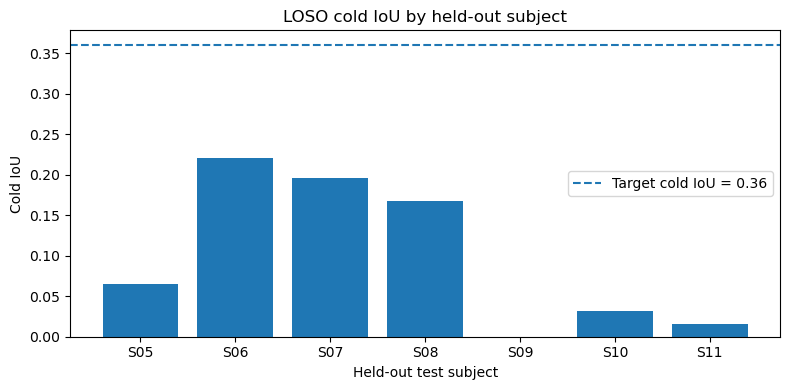

Saved aggregate files in: THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/csv


In [35]:
# ============================================================
# SECTION 12 — AGGREGATE LOSO RESULTS
# ============================================================

def collect_loso_outputs():
    fold_result_paths = sorted(EXP_DIR.glob("fold_*/csv/fold_result.csv"))
    test_summary_paths = sorted(EXP_DIR.glob("fold_*/csv/test_summary.csv"))
    test_case_paths = sorted(EXP_DIR.glob("fold_*/csv/test_per_case.csv"))

    fold_results = pd.concat([pd.read_csv(p) for p in fold_result_paths], ignore_index=True) if fold_result_paths else pd.DataFrame()
    test_summary = pd.concat([pd.read_csv(p) for p in test_summary_paths], ignore_index=True) if test_summary_paths else pd.DataFrame()
    test_cases = pd.concat([pd.read_csv(p) for p in test_case_paths], ignore_index=True) if test_case_paths else pd.DataFrame()

    return fold_results, test_summary, test_cases

fold_results_df, loso_test_summary_df, loso_test_cases_df = collect_loso_outputs()

if len(fold_results_df) == 0:
    raise ValueError("No LOSO fold outputs found. Run Section 11 first.")

fold_results_df.to_csv(CSV_DIR / "91_loso_fold_results_collected.csv", index=False)
loso_test_summary_df.to_csv(CSV_DIR / "92_loso_test_summary_all_folds.csv", index=False)
loso_test_cases_df.to_csv(CSV_DIR / "93_loso_test_per_case_all_folds.csv", index=False)

summary_rows = []
for metric in ["test_body_iou", "test_cold_iou", "test_cold_sensitivity", "test_cold_specificity"]:
    summary_rows.append({
        "metric": metric,
        "mean": fold_results_df[metric].mean(),
        "std": fold_results_df[metric].std(ddof=1),
        "median": fold_results_df[metric].median(),
        "min": fold_results_df[metric].min(),
        "max": fold_results_df[metric].max(),
        "n_folds": len(fold_results_df),
    })

loso_final_summary_df = pd.DataFrame(summary_rows)
loso_final_summary_df.to_csv(CSV_DIR / "94_loso_final_mean_std.csv", index=False)

print("LOSO fold results:")
display(fold_results_df)

print("LOSO final mean/std:")
display(loso_final_summary_df)

plt.figure(figsize=(8, 4))
plt.bar(fold_results_df["test_subject"], fold_results_df["test_cold_iou"])
plt.axhline(0.36, linestyle="--", label="Target cold IoU = 0.36")
plt.xlabel("Held-out test subject")
plt.ylabel("Cold IoU")
plt.title("LOSO cold IoU by held-out subject")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "94_loso_cold_iou_by_subject.png", dpi=200)
plt.show()

print("Saved aggregate files in:", CSV_DIR)

## Section 13 — Visualize worst LOSO test cases

,fold_id,test_subject,case_id,iou,sensitivity,specificity,gt_pixels,pred_pixels
0,2,S07,S07-D-3,0.0,0.0,0.978869,97,1729
1,2,S07,S07-B-1,0.0,0.0,0.975536,454,1993
2,1,S06,S06-D-3,0.0,0.0,0.989182,482,881
3,2,S07,S07-D-2,0.0,0.0,0.977062,134,1876
4,1,S06,S06-D-1,0.0,0.0,0.992423,490,617
5,4,S09,S09-D-3,0.0,0.0,1.000000,668,0
6,5,S10,S10-A-1,0.0,0.0,0.991658,41,683
7,5,S10,S10-B-1,0.0,0.0,1.000000,132,0


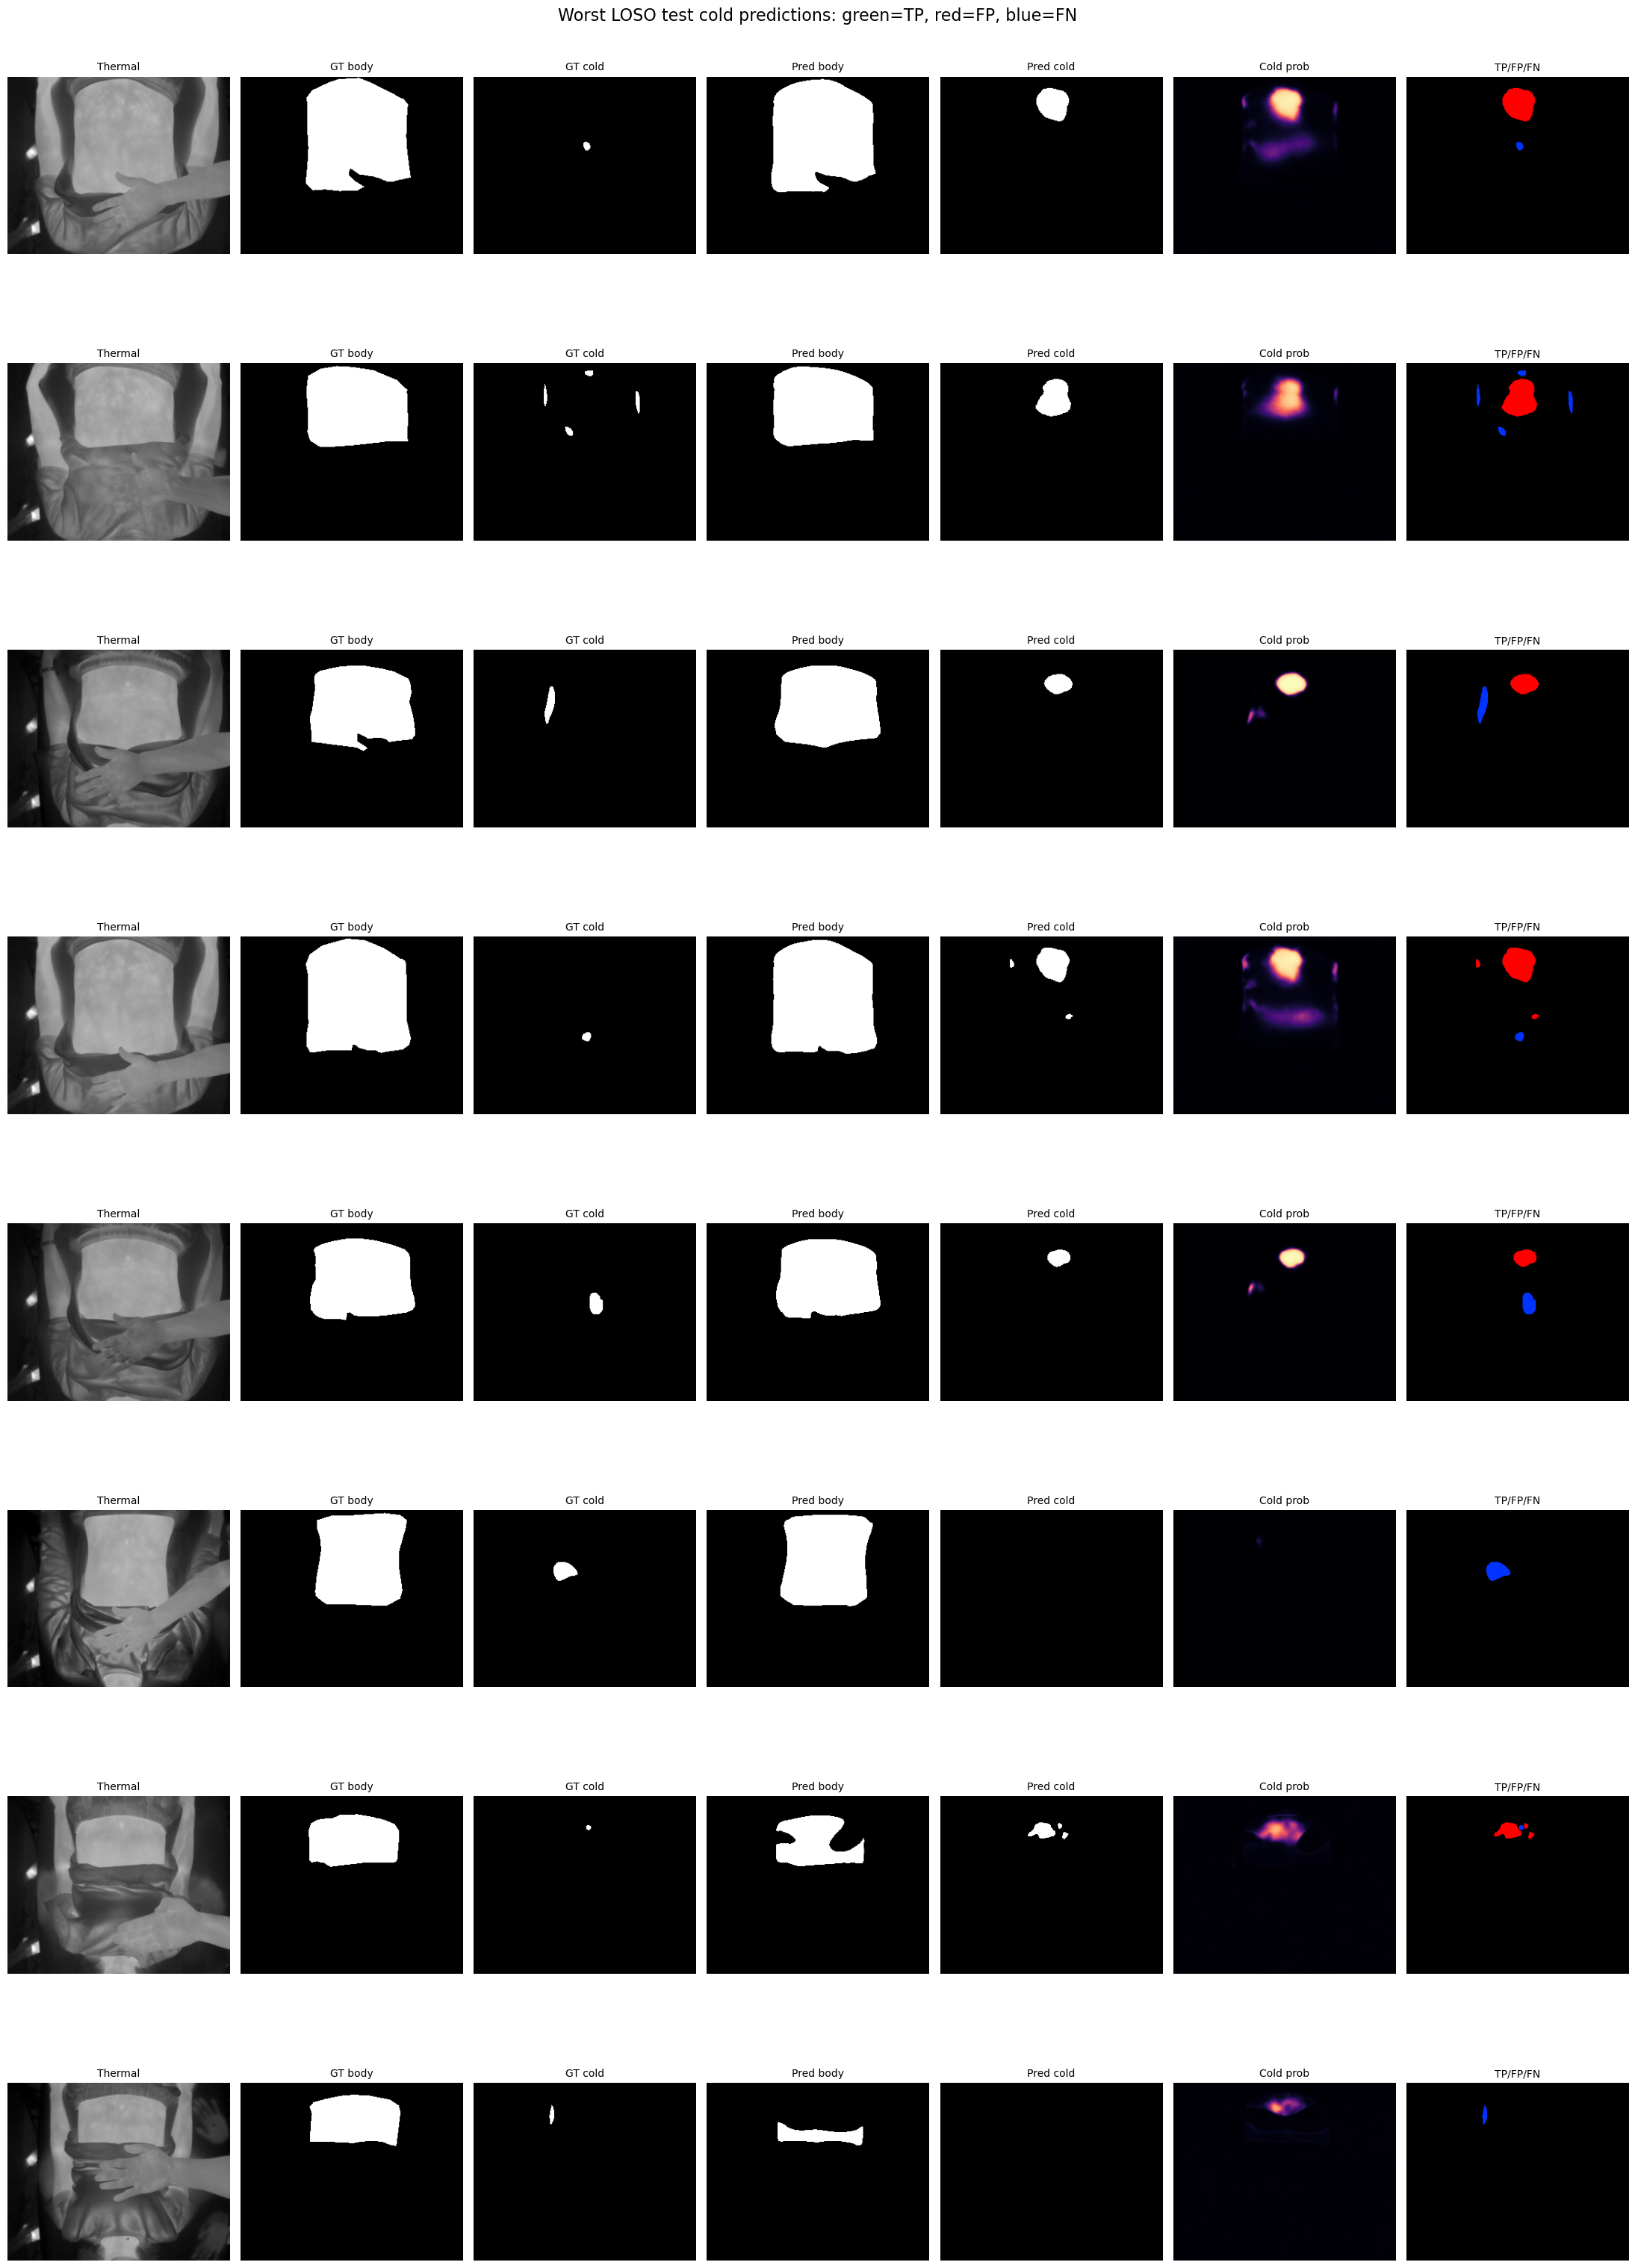

Saved: THERMO_LOSO_RESULTS/loso_hier_unet_baseline_clean/plots/95_worst_loso_test_cases.png


In [36]:
# ============================================================
# SECTION 13 — VISUALIZE WORST LOSO TEST CASES
# ============================================================


def make_error_rgb(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt
    rgb = np.zeros((gt.shape[0], gt.shape[1], 3), dtype=np.float32)
    rgb[tp] = [0.0, 1.0, 0.0]
    rgb[fp] = [1.0, 0.0, 0.0]
    rgb[fn] = [0.0, 0.2, 1.0]
    return rgb


def visualize_worst_loso_cases(n=8):
    fold_results_df, _, test_cases_df = collect_loso_outputs()
    if len(test_cases_df) == 0:
        raise ValueError("No test cases found. Run Sections 11 and 12 first.")

    cold_df = test_cases_df[test_cases_df["class"] == "cold"].copy()
    cold_df = cold_df.sort_values("iou", ascending=True).head(n).reset_index(drop=True)

    display(cold_df[["fold_id", "test_subject", "case_id", "iou", "sensitivity", "specificity", "gt_pixels", "pred_pixels"]])

    n_cases = len(cold_df)
    n_cols = 7
    fig, axes = plt.subplots(n_cases, n_cols, figsize=(22, 4 * n_cases))
    if n_cases == 1:
        axes = axes[None, :]

    for r, metric_row in cold_df.iterrows():
        case_id = metric_row["case_id"]
        fold_id = int(metric_row["fold_id"])
        body_thr = float(metric_row["body_thr"])
        cold_thr = float(metric_row["cold_thr"])
        min_cc = int(metric_row["min_cold_cc"])

        fold_result = fold_results_df[fold_results_df["fold_id"] == fold_id].iloc[0]
        ckpt = torch.load(fold_result["model_path"], map_location=DEVICE)

        model = build_model().to(DEVICE)
        model.load_state_dict(ckpt["model_state"])
        model.eval()

        row = case_df_all[case_df_all["case_id"] == case_id].iloc[0]
        d = np.load(row["npz_path"])
        x4 = d["x4"].astype(np.float32)
        body_gt = d["body_soft"].astype(np.float32) >= 0.5
        cold_gt = d["cold_soft"].astype(np.float32) >= 0.5
        img = d["img_raw"].astype(np.float32)
        img = img - np.nanmin(img)
        img = img / (np.nanmax(img) + 1e-8)

        with torch.no_grad():
            xt = torch.tensor(x4[None], dtype=torch.float32).to(DEVICE)
            logits = model(xt)
            body_prob = torch.sigmoid(logits[:, 0:1])[0, 0].detach().cpu().numpy()
            cold_prob = torch.sigmoid(logits[:, 1:2])[0, 0].detach().cpu().numpy()

        body_pred, cold_pred = postprocess_body_cold(
            body_prob,
            cold_prob,
            body_thr=body_thr,
            cold_thr=cold_thr,
            min_cold_cc=min_cc,
        )

        error_rgb = make_error_rgb(cold_pred, cold_gt)

        imgs = [img, body_gt, cold_gt, body_pred, cold_pred, cold_prob, error_rgb]
        titles = ["Thermal", "GT body", "GT cold", "Pred body", "Pred cold", "Cold prob", "TP/FP/FN"]

        for c in range(n_cols):
            ax = axes[r, c]
            if c == 6:
                ax.imshow(imgs[c])
            elif c == 5:
                ax.imshow(imgs[c], cmap="magma", vmin=0, vmax=1)
            else:
                ax.imshow(imgs[c], cmap="gray")
            ax.set_title(titles[c], fontsize=10)
            ax.axis("off")

        axes[r, 0].set_ylabel(
            f"fold {fold_id} / {case_id}\n"
            f"IoU={metric_row['iou']:.3f}\n"
            f"Sens={metric_row['sensitivity']:.3f}\n"
            f"GT={int(metric_row['gt_pixels'])}, Pred={int(metric_row['pred_pixels'])}",
            fontsize=10,
        )

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    plt.suptitle("Worst LOSO test cold predictions: green=TP, red=FP, blue=FN", fontsize=16)
    plt.tight_layout()
    save_path = PLOT_DIR / "95_worst_loso_test_cases.png"
    plt.savefig(save_path, dpi=200)
    plt.show()
    print("Saved:", save_path)

visualize_worst_loso_cases(n=8)